In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Encoder | Decoder</h1>
<h3 style="margin: 0;  color: #1e1a66">shallow networks</h3>
</div>

Imports:

In [7]:
import numpy as np
import torch
from torch import nn

import matplotlib.pyplot as plt

from Utilities.Exchanger_Device import compute_U_P_solution_exchanger_device

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    plot_viscosity,
    Plot_Velocity_and_Pressure,
)

from Data_Generation.data_utils import(
    load_mesh_data,
    load_parameters_data
)

from Data_Generation.stokes_dataset import StokesDataset
from torch.utils.data import DataLoader

---

We begin with loading and storing data in the raw data matrix $\mathbf{X} \in \mathbb{R}^{N_v \times (3+4k)}$, the $i^{th}$ row is defined as follows:

$$
\tilde{x}_i = 
\begin{bmatrix} 
x_i \\ y_i \\ \mu_1 \\ \vdots \\ \mu_k \\ p^{x}_{i,1} \\ \vdots \\ p^{x}_{i,k} \\ p^{y}_{i,1} \\ \vdots \\ p^{y}_{i,k} \\ \hat{w}_{i,1} \\ \vdots \\ \hat{w}_{i,k} \\ b_i
\end{bmatrix} \in \mathbb{R}^{3+4k}
\qquad
\mathbf{X} = 
\begin{bmatrix} 
(\tilde{x}_1)^T \\ (\tilde{x}_2)^T \\ \vdots \\ (\tilde{x}_{N_v})^T 
\end{bmatrix} 
=
\begin{bmatrix}
x_1 & y_1 & \mu_1 & \cdots & \mu_k & p^{x}_{1,1} & \cdots & p^{x}_{1,k} & p^{y}_{1,1} & \cdots & p^{y}_{1,k} & \hat{w}_{1,1} & \cdots & \hat{w}_{1,k} & b_1 \\
x_2 & y_2 & \mu_1 & \cdots & \mu_k & p^{x}_{2,1} & \cdots & p^{x}_{2,k} & p^{y}_{2,1} & \cdots & p^{y}_{2,k} & \hat{w}_{2,1} & \cdots & \hat{w}_{2,k} & b_2 \\
\vdots & \vdots & \vdots & & \vdots & \vdots &  & \vdots & \vdots & & \vdots & \vdots & & \vdots & \vdots \\
x_{N_v} & y_{N_v} & \mu_1 & \cdots & \mu_k & p^{x}_{{N_v},1} & \cdots & p^{x}_{{N_v},k} & p^{y}_{{N_v},1} & \cdots & p^{y}_{{N_v},k} & \hat{w}_{{N_v},1} & \cdots & \hat{w}_{{N_v},k} & b_{N_v}
\end{bmatrix} \in \mathbb{R}^{N_v \times (3+4k)}
$$

where:

* $(x_i, y_i)$ are the spatial coordinates of node $i$, denoted as $x_i \in \Omega$.


* $\boldsymbol{\mu} = [\mu_1, \dots, \mu_p]^\top$ are the prescribed global viscosity parameters at the $p$ control points.


* $(p^x_m, p^y_m)$ are the spatial coordinates of the $m$-th control point $x_m$ for $m \in \{1, \dots, p\}$.


* $\psi_m(x_i) = \frac{w_m(x_i)}{\sum_{j=1}^p w_j(x_i)}$ is the normalized Shepard basis function for control point $m$ evaluated at node $x_i$.


* $w_m(x_i) = \frac{1}{\max(d_m, \epsilon)^\gamma}$ is the inverse-distance weight, where $d_m = \vert{}x_i - x_m\vert{}_2$ is the Euclidean distance from node $x_i$ to control point $x_m$, $\epsilon$ is the softening parameter, and $\gamma$ is the decay power.


* $b_i$ is the boundary condition flag for node $i$ extracted from the mesh geometry.

---

In [3]:
p_fine, e_fine, t_fine, p_coarse, e_coarse, t_coarse, b_nodes = load_mesh_data('Data_Generation/Data/ex_dev.npz')
mu_values, mu_loc, bases = load_parameters_data('Data_Generation/Data/params.npz')

def get_size_mb(arr: np.ndarray) -> float:
    return arr.nbytes / (1024 ** 2)

print("=" * 90)
print(f"{'DATASET SUMMARY & TENSOR DIMENSIONS':^80}")
print("—" * 90)

print("\n——— 1. MESH GEOMETRY (ex_dev.npz) ———")
print(f"  Fine Nodes    (p_fine)   : Shape {str(p_fine.shape):<18} | Dtype: {str(p_fine.dtype):<7} | Mem: {get_size_mb(p_fine):.2f} MB")
print(f"  Fine Edges    (e_fine)   : Shape {str(e_fine.shape):<18} | Dtype: {str(e_fine.dtype):<7} | Mem: {get_size_mb(e_fine):.2f} MB")
print(f"  Fine Triangles(t_fine)   : Shape {str(t_fine.shape):<18} | Dtype: {str(t_fine.dtype):<7} | Mem: {get_size_mb(t_fine):.2f} MB")
print(f"  Coarse Nodes  (p_coarse) : Shape {str(p_coarse.shape):<18} | Dtype: {str(p_coarse.dtype):<7} | Mem: {get_size_mb(p_coarse):.2f} MB")
print(f"  Coarse Edges  (e_coarse) : Shape {str(e_coarse.shape):<18} | Dtype: {str(e_coarse.dtype):<7} | Mem: {get_size_mb(e_coarse):.2f} MB")
print(f"  Coarse Tris   (t_coarse) : Shape {str(t_coarse.shape):<18} | Dtype: {str(t_coarse.dtype):<7} | Mem: {get_size_mb(t_coarse):.2f} MB")
print(f"  Boundary Nodes(b_nodes)  : Shape {str(b_nodes.shape):<18} | Dtype: {str(b_nodes.dtype):<7} | Mem: {get_size_mb(b_nodes):.2f} MB")

print("\n——— 2. PARAMETERS & RBF BASES (params.npz) ———")
print(f"  Viscosity μ      (mu_values) : Shape {str(mu_values.shape):<18} | Dtype: {str(mu_values.dtype):<7} | Mem: {get_size_mb(mu_values):.2f} MB")
print(f"  Control Locations(mu_loc)    : Shape {str(mu_loc.shape):<18} | Dtype: {str(mu_loc.dtype):<7} | Mem: {get_size_mb(mu_loc):.2f} MB")
print(f"  RBF Bases        (bases)     : Shape {str(bases.shape):<18} | Dtype: {str(bases.dtype):<7} | Mem: {get_size_mb(bases):.2f} MB")

total_mem = sum(get_size_mb(x) for x in [p_fine, e_fine, t_fine, p_coarse, e_coarse, t_coarse, b_nodes, mu_values, mu_loc, bases])

print("\n——— 3. MAIN METRICS ———")
print(f"  • Total Dataset Samples (N_samples) : {mu_values.shape[0]}")
print(f"  • Fine Mesh Sequence Length (N_v)   : {p_fine.shape[0]} nodes")
print(f"  • RBF Knobs per Sample (k)          : {mu_values.shape[1]}")
print(f"  • Boundary Nodes Count              : {len(b_nodes)} ({np.sum(b_nodes)/p_fine.shape[0]*100:.1f}% of mesh)")
print(f"  • Viscosity Range                   : [{mu_values.min():.2f}, {mu_values.max():.2f}] units")
print(f"  • Total RAM Footprint in Memory     : {total_mem:.2f} MB")
print("—" * 90)

                      DATASET SUMMARY & TENSOR DIMENSIONS                       
——————————————————————————————————————————————————————————————————————————————————————————

——— 1. MESH GEOMETRY (ex_dev.npz) ———
  Fine Nodes    (p_fine)   : Shape (5899, 2)          | Dtype: float64 | Mem: 0.09 MB
  Fine Edges    (e_fine)   : Shape (17178, 3)         | Dtype: int32   | Mem: 0.20 MB
  Fine Triangles(t_fine)   : Shape (11280, 7)         | Dtype: int32   | Mem: 0.30 MB
  Coarse Nodes  (p_coarse) : Shape (1540, 2)          | Dtype: float64 | Mem: 0.02 MB
  Coarse Edges  (e_coarse) : Shape (4359, 3)          | Dtype: int32   | Mem: 0.05 MB
  Coarse Tris   (t_coarse) : Shape (2820, 7)          | Dtype: int32   | Mem: 0.08 MB
  Boundary Nodes(b_nodes)  : Shape (5899, 1)          | Dtype: float32 | Mem: 0.02 MB

——— 2. PARAMETERS & RBF BASES (params.npz) ———
  Viscosity μ      (mu_values) : Shape (700, 9)           | Dtype: float32 | Mem: 0.02 MB
  Control Locations(mu_loc)    : Shape (700, 9, 2

Investigating a random sample from the dataset:

sample idx : 292
mu vector  : [32.64 11.04 80.29 49.67 23.43 50.39 30.89 80.49 71.86]


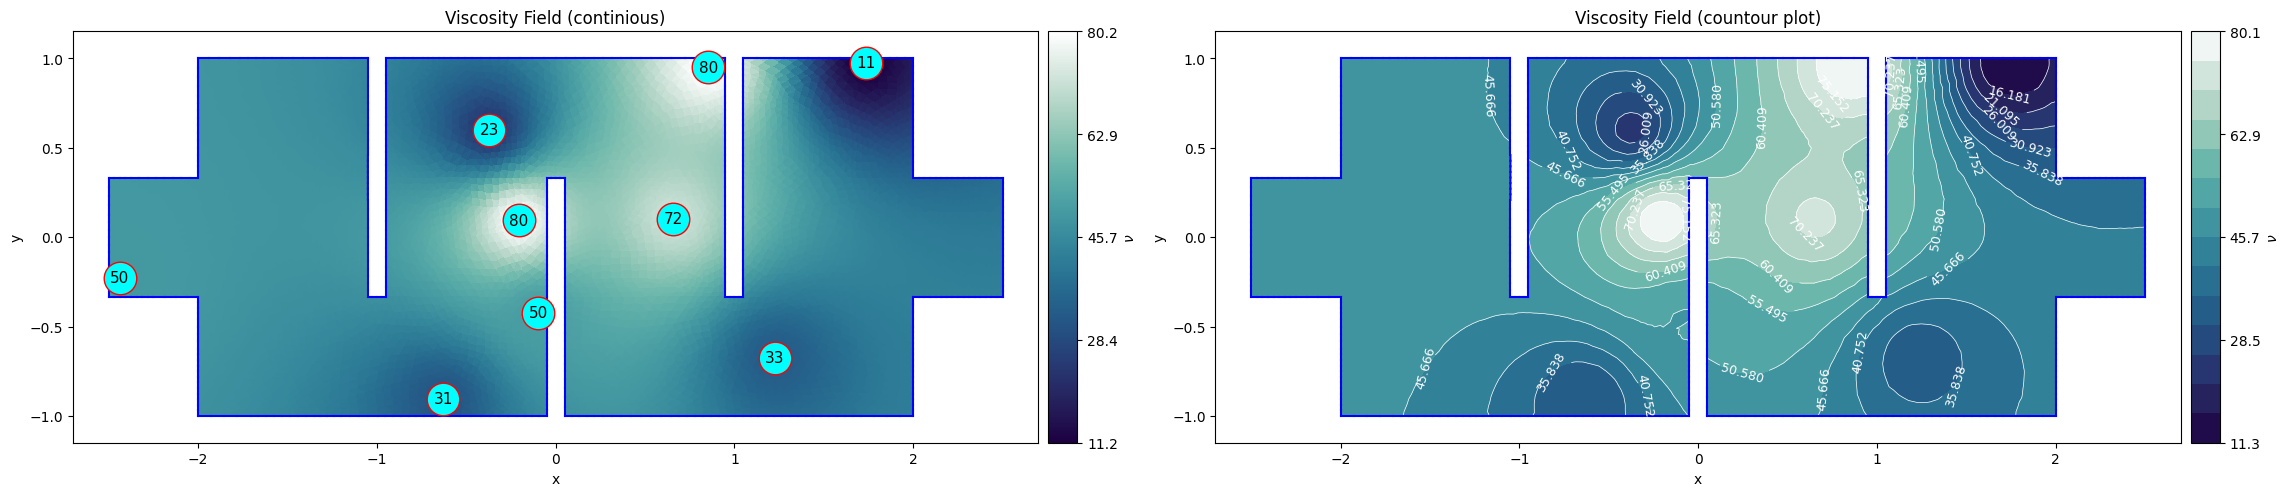

In [4]:
random_sample = np.random.randint(low=0, high=mu_values.shape[0])
parameter_loc = mu_loc[random_sample, :, :]
mu = mu_values[random_sample, :]
psi_field = bases[random_sample, :, :]

kinematic_viscosity = psi_field @ mu
kinematic_viscosity_elem = kinematic_viscosity[t_fine[:, :3]].mean(axis=1)

nu_dict = {
        "pts":  parameter_loc,
        "vals": mu
    }

print(f"sample idx : {random_sample}\nmu vector  : {np.round(mu, 2)}")
plot_viscosity(p_fine, t_fine, e_fine, kinematic_viscosity_elem, nu_dict, 
               n_levels=15, figsize=(23, 10), 
               name=f'{mu}', savetype="png")

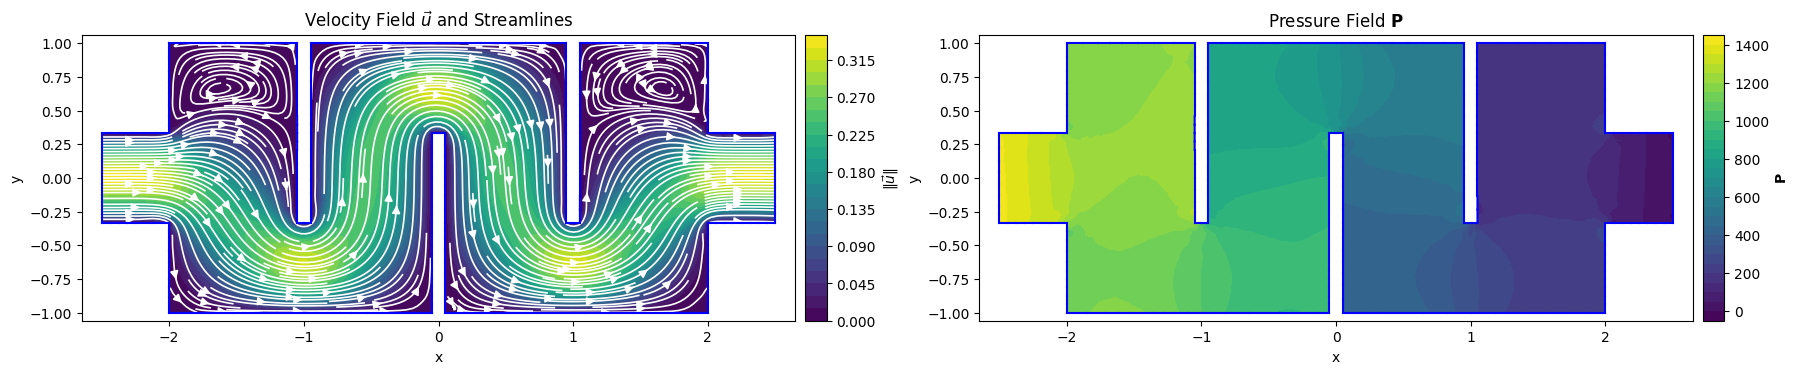

In [5]:
ux, uy, p_sol = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse, kinematic_viscosity=kinematic_viscosity_elem)
Plot_Velocity_and_Pressure(p_fine, t_fine, p_coarse, t_coarse, e_coarse, ux, uy, p_sol, name='')

### Dataset tensor $\mathbf X \in \mathbb{R}^{N_s \times N_v \times (3+4k)}$:

In [ ]:
dataset = StokesDataset(
    p=p_fine[:, :2],
    flag=b_nodes.ravel(),
    mu_locs=mu_loc,
    mu_params=mu_values,
    bases=bases,
    mu_range=[0.1, 100.0],
    k_params=9
)

train_loader = DataLoader(
    dataset, 
    batch_size=16, 
    shuffle=True, 
    num_workers=0
)

first_batch = next(iter(train_loader))

print("—" * 90)
print(f"Dataset Length          : {len(dataset)} samples")
print(f"Single Sample Shape     : {dataset[0].shape} (N_v, Features)")
print(f"Batch Shape             : {first_batch.shape} (Batch, N_v, Features)")
print(f"Tensor Data Type        : {first_batch.dtype}")
print(f"Value Range (Min / Max) : [{first_batch.min():.3f}, {first_batch.max():.3f}]")
print("—" * 90)

——————————————————————————————————————————————————————————————————————————————————————————
Dataset Length          : 700 samples
Single Sample Shape     : torch.Size([5899, 39]) (N_v, Features)
Batch Shape             : torch.Size([16, 5899, 39]) (Batch, N_v, Features)
Tensor Data Type        : torch.float32
Value Range (Min / Max) : [-1.855, 8.014]
——————————————————————————————————————————————————————————————————————————————————————————


### Single data matrix $\mathbf X \in \mathbb{R}^{N_v \times (3+4k)}$:

In [ ]:
X_scaled = first_batch[0, :, :]

print(f"X Shape      : {X_scaled.shape}")
print(f"Contains NaN : {np.isnan(X_scaled).any().item()}")
print(f"Contains Inf : {np.isinf(X_scaled).any().item()}")
print(f"Mean Value   : {X_scaled.mean().item():.4f}")
print(f"Std Dev      : {X_scaled.std().item():.4f}")

---

### Embedding/Token matrix $\mathbf{E} \in \mathbb{R}^{N \times d}$:

$$
\mathbf{E} = \sigma(\mathbf{H} \mathbf{W}_2 + \mathbf{1}_{N_v} \mathbf{b}_2^T)
$$

In [11]:
class Shallow_MLP_Encoder(nn.Module):
    def __init__(self, n_predictors, d_hidden):
        super().__init__()
        self.d = d_hidden
        self.p = n_predictors

        std = np.sqrt(2.0 / self.p) # Kaiming normal scaling
        self.W_x  = nn.Parameter(torch.randn(size=(self.p, self.d), dtype=torch.float32) * std)
        self.b_x  = nn.Parameter(torch.randn(size=(1, self.d),      dtype=torch.float32))
        self.gelu = nn.GELU()

    def forward(self, x):
        x = x @ self.W_x + self.b_x
        e = self.gelu(x)
        return e

In [12]:
n_predictors = X_scaled.shape[1]    # (3 + 4k) features 
d_hidden = 128                      # latent embedding dimension

encoder = Shallow_MLP_Encoder(n_predictors=n_predictors, d_hidden=d_hidden)
X_input = X_scaled.float()
if X_input.ndim == 2:
    X_input = X_input.unsqueeze(0)  # [1, 5899, 31]

E_matrix = encoder(X_input)

Input Shape             : torch.Size([1, 5899, 39])
Output Shape            : torch.Size([1, 5899, 128])
Contains NaN            : False
Contains Inf            : False
Mean Value              : 0.4952
Std Dev                 : 0.8839
Spatial Var across Nodes: 0.4266


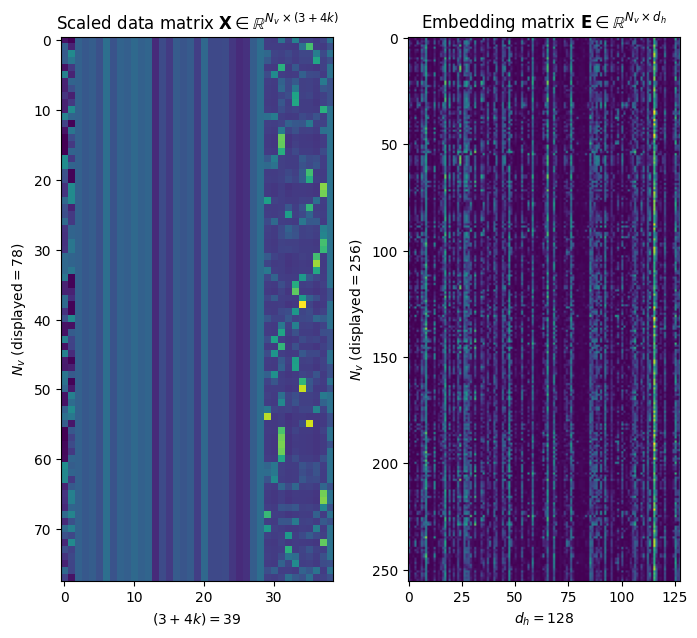

In [13]:
print(f"Input Shape             : {X_input.shape}")
print(f"Output Shape            : {E_matrix.shape}")
print(f"Contains NaN            : {torch.isnan(E_matrix).any().item()}")
print(f"Contains Inf            : {torch.isinf(E_matrix).any().item()}")
print(f"Mean Value              : {E_matrix.mean().item():.4f}")
print(f"Std Dev                 : {E_matrix.std().item():.4f}")
print(f"Spatial Var across Nodes: {E_matrix.std(dim=1).mean().item():.4f}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7,7), dpi=100)
display_len_X, display_len_E = n_predictors*2, d_hidden*2
ax[0].set_title('Scaled data matrix $\\mathbf{X} \\in \\mathbb{R}^{N_v \\times (3+4k)}$')
ax[0].imshow(X_scaled.detach().cpu().numpy()[:display_len_X, :], aspect='equal')
ax[0].set_ylabel(rf'$N_v$ (displayed$={{{display_len_X}}}$)')
ax[0].set_xlabel(rf'$(3+4k) = {{{n_predictors}}}$')

ax[1].set_title('Embedding matrix $\\mathbf{E} \\in \\mathbb{R}^{N_v \\times d_{h}}$')
ax[1].imshow(E_matrix.squeeze().detach().cpu().numpy()[:display_len_E, :], aspect='equal')
ax[1].set_ylabel(rf'$N_v$ (displayed$={{{display_len_E}}}$)')
ax[1].set_xlabel(rf'$d_h = {{{d_hidden}}}$')

fig.tight_layout()
plt.savefig(f'Outputs/Raw&Embedded_data.png', bbox_inches='tight', pad_inches=0.01)
plt.show()